# **Automobile market segmentation using cluster**

Team :JADHAV CHANDRASHEKAR [92460118885]
        SHIVAM MISHRA[92460118889]


**To group cars into different segments based on price, engine power, and mileage.**

 • Data Loading
We upload and read the dataset for analysis.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


• Data Exploration
Understanding dataset structure and features.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("data.csv")

In [ ]:
print("First 5 records:")
display(df.head())

First 5 records:


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [ ]:
print(f"\nDataset Shape: {df.shape}")



Dataset Shape: (11914, 16)


In [ ]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: floa

• Handling Missing Values
Checking and removing missing values.

In [ ]:
print("\nMissing Values Count:")
print(df.isnull().sum())


Missing Values Count:
Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64


• Feature Selection
We select important features for clustering.

In [ ]:
features = ['MSRP', 'Engine HP', 'highway MPG']
x = df[features].copy()

In [ ]:
x = x.dropna(subset=['MSRP', 'Engine HP', 'highway MPG'])

• Data Cleaning
Removing missing values and duplicates.

In [ ]:
x = x.drop_duplicates()

In [ ]:
print("\nShape after cleaning:", x.shape)
print("\nMissing values after cleaning:")
print(x.isnull().sum())


Shape after cleaning: (9925, 3)

Missing values after cleaning:
MSRP           0
Engine HP      0
highway MPG    0
dtype: int64


In [ ]:
print(x.head())

    MSRP  Engine HP  highway MPG
0  46135      335.0           26
1  40650      300.0           28
2  36350      300.0           28
3  29450      230.0           28
4  34500      230.0           28


• Feature Scaling
Standardizing data for better clustering performance.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
x_scaled = scaler.fit_transform(x)

• Model Building
Applying K-Means clustering to segment cars.

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

In [ ]:
kmeans.fit(x_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [ ]:
x['Segment'] = kmeans.fit_predict(x_scaled)

• Cluster Centers
Understanding characteristics of each segment.

In [ ]:
scaler.fit(x[features])
centers = scaler.inverse_transform(kmeans.cluster_centers_)
segment_profiles = pd.DataFrame(centers, columns=features)
segment_profiles.index = ['Economy Commuters', 'Mid-Range Family', 'Luxury Sports']
print(centers)
print("\n--- Real-World Averages for Each Market Segment ---")
print(np.round(segment_profiles, 2))

[[2.39518898e+04 1.69544976e+02 3.24687007e+01]
 [3.82163776e+04 2.85838027e+02 2.29883408e+01]
 [2.17765064e+05 5.43129562e+02 1.93813869e+01]]

--- Real-World Averages for Each Market Segment ---
                        MSRP  Engine HP  highway MPG
Economy Commuters   23951.89     169.54        32.47
Mid-Range Family    38216.38     285.84        22.99
Luxury Sports      217765.06     543.13        19.38


 • Visualization
Visualizing clusters based on features.

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'Automobile Segments: Price vs. Horsepower')

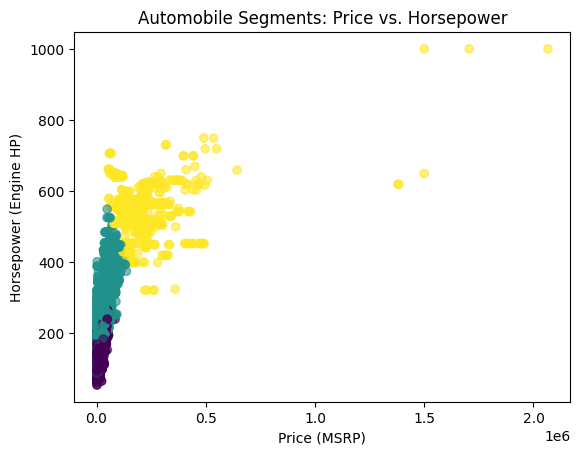

In [ ]:
scatter = plt.scatter(x['MSRP'], x['Engine HP'], c=x['Segment'], cmap='viridis', alpha=0.6)

plt.xlabel('Price (MSRP)')
plt.ylabel('Horsepower (Engine HP)')
plt.title('Automobile Segments: Price vs. Horsepower')

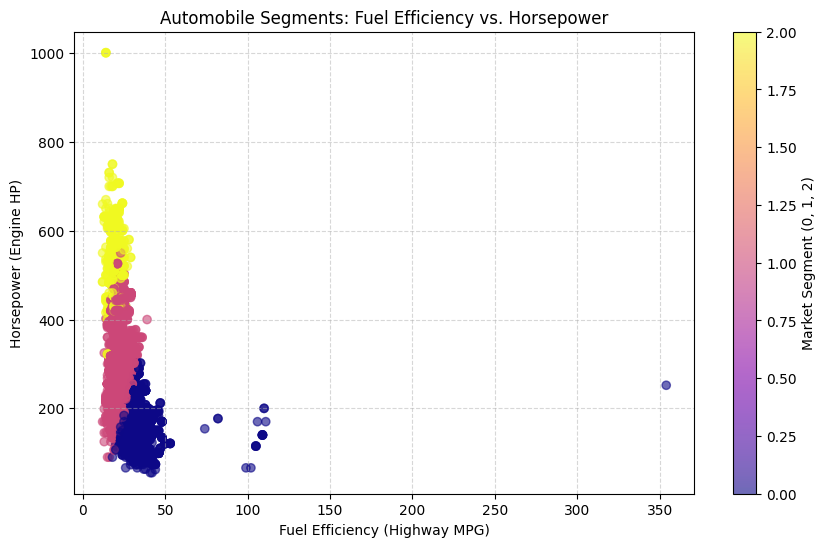

In [ ]:
plt.figure(figsize=(10, 6))
scatter2 = plt.scatter(x['highway MPG'], x['Engine HP'], c=x['Segment'], cmap='plasma', alpha=0.6)
plt.xlabel('Fuel Efficiency (Highway MPG)')
plt.ylabel('Horsepower (Engine HP)')
plt.title('Automobile Segments: Fuel Efficiency vs. Horsepower')
plt.colorbar(scatter2, label='Market Segment (0, 1, 2)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

✅ Conclusion

- Cars are grouped into 3 segments
- Based on price, power, and mileage
- Helps companies in marketing and targeting customers


Future Scope:
- Use more features
- Try advanced clustering models